# Modelado de la Curva de Crecimiento de Interacciones

El objetivo de este notebook es:
1. Descargar (cargar) todas las publicaciones de los candidatos de Costa Rica.
2. Construir la curva de crecimiento de las interacciones a lo largo del tiempo.
3. Realizar pruebas estadísticas para determinar la distribución que mejor modela la curva (0 a 100%).
4. Proveer una función que, dada una fecha de publicación y un número de interacciones totales, reconstruya el crecimiento diario.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Carga y Preparación de Datos

In [2]:
file_path = 'Scrapping data v2.xlsx'
xl = pd.ExcelFile(file_path)

df_fb = pd.read_excel(xl, sheet_name='Facebook')
df_ig = pd.read_excel(xl, sheet_name='Instagram')
df_tk = pd.read_excel(xl, sheet_name='TikTok')
df_tw = pd.read_excel(xl, sheet_name='Twitter')

def generate_id(text):
    if pd.isna(text): return "missing_text"
    return hashlib.md5(str(text).encode('utf-8')).hexdigest()

if df_tw['postId'].isnull().all() or df_tw['postId'].astype(str).str.strip().eq('').all():
    df_tw['postId'] = df_tw['text'].apply(generate_id)

def prepare_evolution_df(df, platform, mapping, user_col, id_col, date_pub_col):
    df = df.copy()
    df.columns = df.columns.astype(str).str.strip()
    
    actual_user_col = next((col for col in [user_col, 'Username', 'name', 'Candidato'] if col in df.columns), None)
    if actual_user_col:
        df['candidate'] = df[actual_user_col].astype(str)
    else:
        df['candidate'] = "Desconocido"
    
    df = df[~df['candidate'].str.contains('Desconocido|nan|None', case=False, na=True)]
    df['platform'] = platform
    df['internal_post_id'] = platform + "_" + df[id_col].astype(str)
    df = df.rename(columns=mapping)
    
    p_col = 'fecha_pub' if 'fecha_pub' in df.columns else (date_pub_col if date_pub_col in df.columns else None)
    df['fecha_ext'] = pd.to_datetime(df['fecha_ext'], errors='coerce', dayfirst=True).dt.tz_localize(None)
    df['fecha_pub'] = pd.to_datetime(df[p_col], errors='coerce', dayfirst=True).dt.tz_localize(None)
    df['dia_relativo'] = (df['fecha_ext'] - df['fecha_pub']).dt.days + 1
    
    for col in ['likes', 'comments', 'shares']:
        if col in df.columns: df[col] = pd.to_numeric(df[col], errors='coerce')
        else: df[col] = 0.0
            
    return df[['internal_post_id', 'platform', 'candidate', 'fecha_pub', 'dia_relativo', 'likes', 'comments', 'shares']]

ev_fb = prepare_evolution_df(df_fb, 'Facebook', {'megusta': 'likes', 'comentarios': 'comments', 'compartidas': 'shares'}, 'Username', 'postId', 'fecha_pub')
ev_ig = prepare_evolution_df(df_ig, 'Instagram', {'megusta': 'likes', 'comentarios': 'comments'}, 'Username', 'postId', 'fecha_pub')
ev_tk = prepare_evolution_df(df_tk, 'TikTok', {'megusta': 'likes', 'comentarios': 'comments', 'compartidos': 'shares'}, 'Username', 'postId', 'fecha_pub')
ev_tw = prepare_evolution_df(df_tw, 'Twitter', {'likecount': 'likes', 'replycount': 'comments', 'retweet_count': 'shares'}, 'Username', 'postId', 'createdat')

df_combined = pd.concat([ev_fb, ev_ig, ev_tk, ev_tw], ignore_index=True)
df_combined['total_int'] = df_combined['likes'] + df_combined['comments'] + df_combined['shares']

## 2. Construcción Robusta de la Curva de Crecimiento
Aplicamos interpolación lineal para rellenar días sin mediciones y función acumulativa para asegurar que la curva sea monótonamente creciente y no caiga por problemas de scraping.

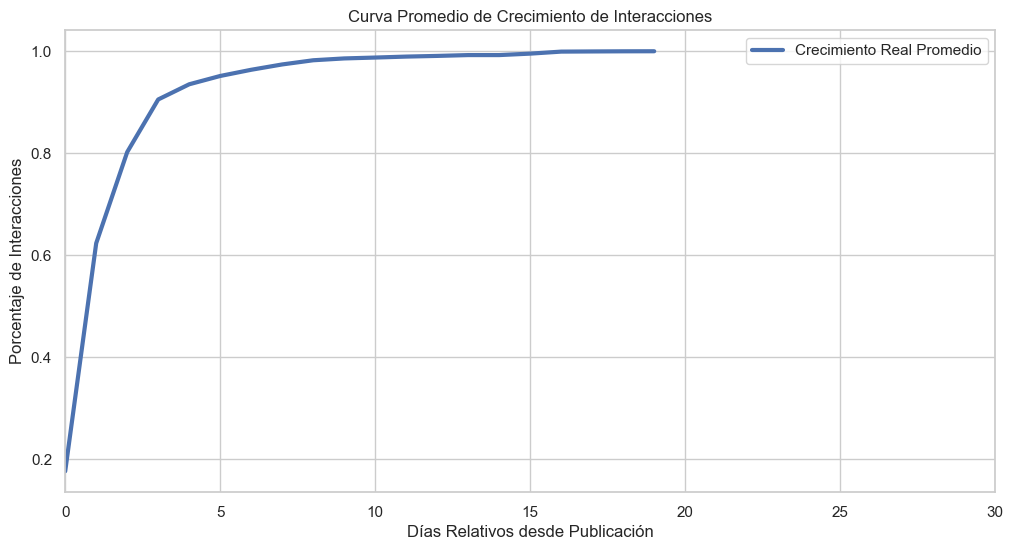

In [3]:
def interpolate_and_calc_pct(group):
    group = group.sort_values('dia_relativo').drop_duplicates('dia_relativo')
    if len(group) < 1: return None
    
    # Hacer que la curva sea no decreciente
    group['total_int'] = group['total_int'].cummax()
    
    min_day = int(group['dia_relativo'].min())
    max_day = int(group['dia_relativo'].max())
    
    if max_day > min_day:
        full_range = pd.DataFrame({'dia_relativo': range(min_day, max_day + 1)})
        # Extraer metadatos para preservarlos
        meta_cols = [c for c in ['internal_post_id', 'platform', 'candidate', 'fecha_pub'] if c in group.columns]
        meta = group.iloc[0][meta_cols] if meta_cols else None
        
        group = pd.merge(full_range, group, on='dia_relativo', how='left')
        if meta is not None:
            for col in meta_cols: group[col] = meta[col]
            
        group['total_int'] = group['total_int'].interpolate(method='linear')
    
    total = group['total_int'].max()
    group['total_int_pct'] = (group['total_int'] / total) if total > 0 else 0
        
    return group

df_pct = df_combined.groupby('internal_post_id', group_keys=False).apply(interpolate_and_calc_pct)

# Encontrar curva promedio
avg_curve = df_pct.groupby('dia_relativo')['total_int_pct'].mean().reset_index()
avg_curve['total_int_pct'] = avg_curve['total_int_pct'].cummax() # Forward fill bias de composicion

plt.plot(avg_curve['dia_relativo'], avg_curve['total_int_pct'], label='Crecimiento Real Promedio', linewidth=3)
plt.xlim(0, 30)
plt.title('Curva Promedio de Crecimiento de Interacciones')
plt.xlabel('Días Relativos desde Publicación')
plt.ylabel('Porcentaje de Interacciones')
plt.legend()
plt.show()

## 3. Pruebas Estadísticas y Selección de Modelo
Ajustaremos distribuciones comunes para modelar este crecimiento (Logística, Gompertz y Exponencial) y seleccionaremos la mejor utilizando métricas como el Error Cuadrático Medio (RMSE) y el R².

Modelo: Logística | R²: 0.9807 | RMSE: 0.0265 | Params: [0.9814444  1.49749571 0.80631442]
Modelo: Gompertz | R²: 0.9905 | RMSE: 0.0185 | Params: [0.98446971 1.58103693 1.09312773]
Modelo: Exponencial CDF | R²: 0.9464 | RMSE: 0.0440 | Params: [0.86186105]
Modelo: Weibull CDF | R²: 0.9558 | RMSE: 0.0400 | Params: [0.99217809 0.71401708]


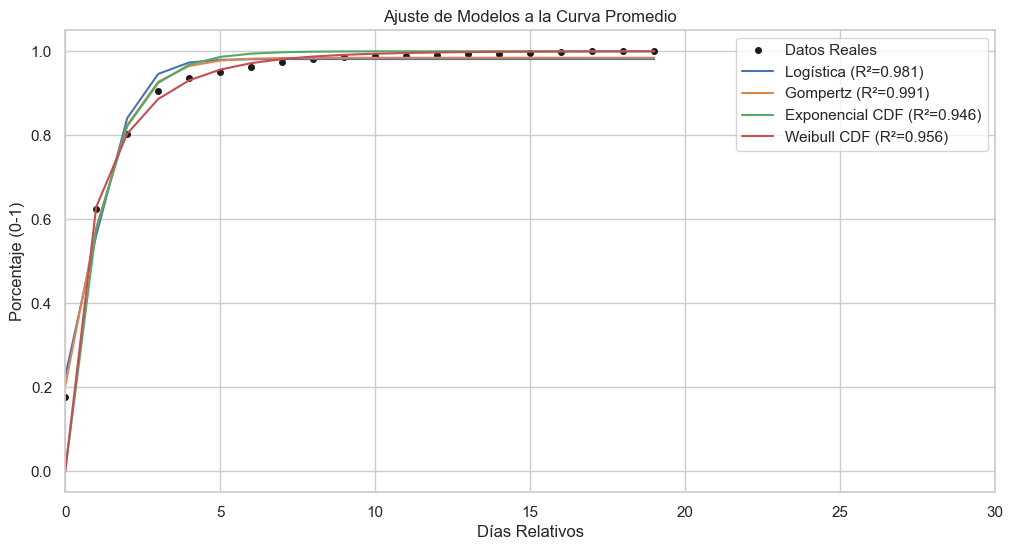


El mejor modelo para describir la curva es: Gompertz con R² = 0.9905


In [11]:
x_data = avg_curve['dia_relativo'].values
y_data = avg_curve['total_int_pct'].values

# 1. Definimos las funciones (incluyendo Weibull)
def logistic_curve(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

def gompertz_curve(x, a, b, c):
    return a * np.exp(-b * np.exp(-c * x))

def exponential_cdf(x, lam):
    from scipy.stats import expon
    return expon.cdf(x, scale=1/lam)

def weibull_cdf(x, k, alpha):
    # F(t) = 1 - e^(-k * t^alpha)
    return 1 - np.exp(-k * (x ** alpha))

# 2. Lista de modelos con múltiples puntos de inicio (p0)
models = [
    ('Logística', logistic_curve, [ [1, 1, 1], [1, 0.1, 5], [1, 0.5, 2] ]),
    ('Gompertz', gompertz_curve, [ [1, 1, 1], [1, 0.1, 0.1], [1, 0.5, 0.5] ]),
    ('Exponencial CDF', exponential_cdf, [ [1], [0.5], [0.1] ]),
    ('Weibull CDF', weibull_cdf, [ [1, 1], [0.1, 0.5], [0.5, 2], [0.01, 1.5] ])
]

best_model = None
best_r2 = -np.inf
best_params = None
best_func = None

plt.figure(figsize=(12, 6))
plt.plot(x_data, y_data, 'ko', label='Datos Reales', markersize=4)

for name, func, p0_options in models:
    best_local_r2 = -np.inf
    best_local_popt = None
    best_local_pred = None
    
    # 3. Intentamos ajustar iterando sobre los diferentes parámetros iniciales
    for p0 in p0_options:
        try:
            # bounds=(0, np.inf) fuerza a que los parámetros sean mayores a 0
            popt, _ = curve_fit(func, x_data, y_data, p0=p0, maxfev=20000, bounds=(0, np.inf))
            y_pred = func(x_data, *popt)
            r2 = r2_score(y_data, y_pred)
            
            # Si este ajuste es mejor que los intentos anteriores, lo guardamos
            if r2 > best_local_r2:
                best_local_r2 = r2
                best_local_popt = popt
                best_local_pred = y_pred
        except Exception:
            continue
            
    # Si logró ajustar al menos una vez, lo graficamos
    if best_local_popt is not None:
        rmse = np.sqrt(mean_squared_error(y_data, best_local_pred))
        print(f"Modelo: {name} | R²: {best_local_r2:.4f} | RMSE: {rmse:.4f} | Params: {best_local_popt}")
        
        plt.plot(x_data, best_local_pred, label=f"{name} (R²={best_local_r2:.3f})")
        
        # Guardar el mejor modelo global para el resto del notebook
        if best_local_r2 > best_r2:
            best_r2 = best_local_r2
            best_model = name
            best_params = best_local_popt
            best_func = func
    else:
        print(f"Fallo al ajustar {name} con todos los parámetros iniciales.")

plt.xlim(0, 30)
plt.title('Ajuste de Modelos a la Curva Promedio')
plt.xlabel('Días Relativos')
plt.ylabel('Porcentaje (0-1)')
plt.legend()
plt.show()

print(f"\nEl mejor modelo para describir la curva es: {best_model} con R² = {best_r2:.4f}")


## 4. Función de Reconstrucción de la Curva
Utilizaremos el mejor modelo ajustado para crear la función que reconstruye las interacciones de un post dado la fecha y su total.

Ejemplo de crecimiento proyectado para 50000 interacciones:

        Fecha  Día Relativo  Porcentaje Interacciones  Interacciones Estimadas
0  2026-02-01             1                  0.579516                    28976
1  2026-02-02             2                  0.824267                    41213
2  2026-02-03             3                  0.927576                    46379
3  2026-02-04             4                  0.965022                    48251
4  2026-02-05             5                  0.977908                    48895
5  2026-02-06             6                  0.982266                    49113
6  2026-02-07             7                  0.983730                    49187
7  2026-02-08             8                  0.984222                    49211
8  2026-02-09             9                  0.984387                    49219
9  2026-02-10            10                  0.984442                    49222
10 2026-02-11            11                  0.984460                 

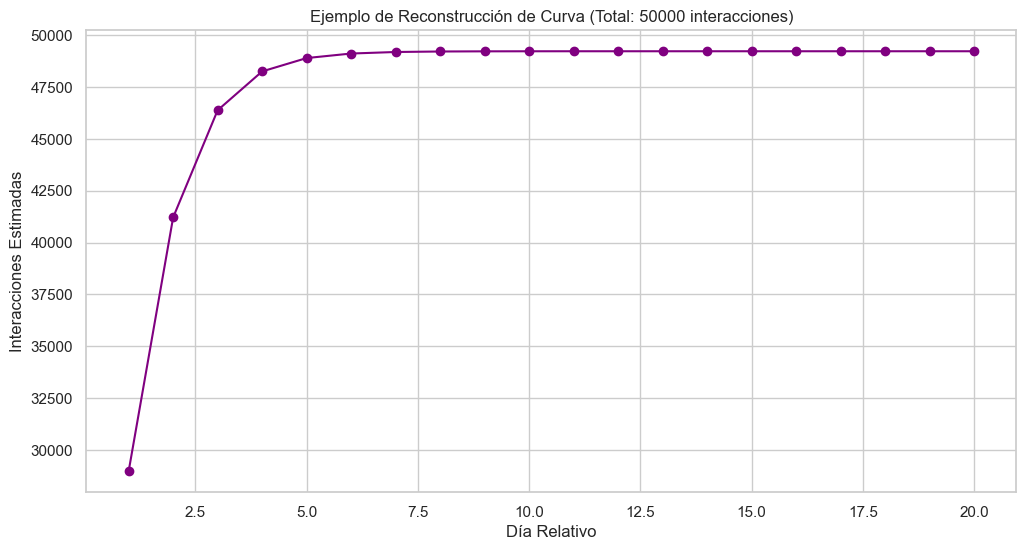

In [12]:
def predict_growth_curve(fecha_pub, total_interacciones, best_func, best_params, dias_maximos=20):
    """
    Genera la curva de crecimiento diario usando el mejor modelo estadístico ajustado.
    
    Parámetros:
    - fecha_pub: string o datetime de la fecha de publicación
    - total_interacciones: int, número de interacciones totales (100%)
    - best_func: función del modelo estadístico seleccionado
    - best_params: parámetros óptimos ajustados (popt)
    - dias_maximos: int, número de días para proyectar la curva
    
    Retorna un DataFrame con la proyección diaria.
    """
    fecha_pub = pd.to_datetime(fecha_pub)
    dias = np.arange(1, dias_maximos + 1)
    
    # Calcular el porcentaje de crecimiento usando el modelo óptimo
    porcentaje_diario = best_func(dias, *best_params)
    
    # Asegurar que esté acotado entre 0 y 1 (o levemente superior por el modelo)
    porcentaje_diario = np.clip(porcentaje_diario, 0, 1)
    
    # Calcular interacciones absolutas y fechas
    fechas = [fecha_pub + pd.Timedelta(days=int(d)-1) for d in dias]
    interacciones_absolutas = np.round(porcentaje_diario * total_interacciones).astype(int)
    
    return pd.DataFrame({
        'Fecha': fechas,
        'Día Relativo': dias,
        'Porcentaje Interacciones': porcentaje_diario,
        'Interacciones Estimadas': interacciones_absolutas
    })

# Ejemplo de uso
ejemplo = predict_growth_curve('2026-02-01', 50000, best_func, best_params)
print("Ejemplo de crecimiento proyectado para 50000 interacciones:\n")
print(ejemplo.head(100))

plt.plot(ejemplo['Día Relativo'], ejemplo['Interacciones Estimadas'], marker='o', color='purple')
plt.title('Ejemplo de Reconstrucción de Curva (Total: 50000 interacciones)')
plt.xlabel('Día Relativo')
plt.ylabel('Interacciones Estimadas')
plt.show()